In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

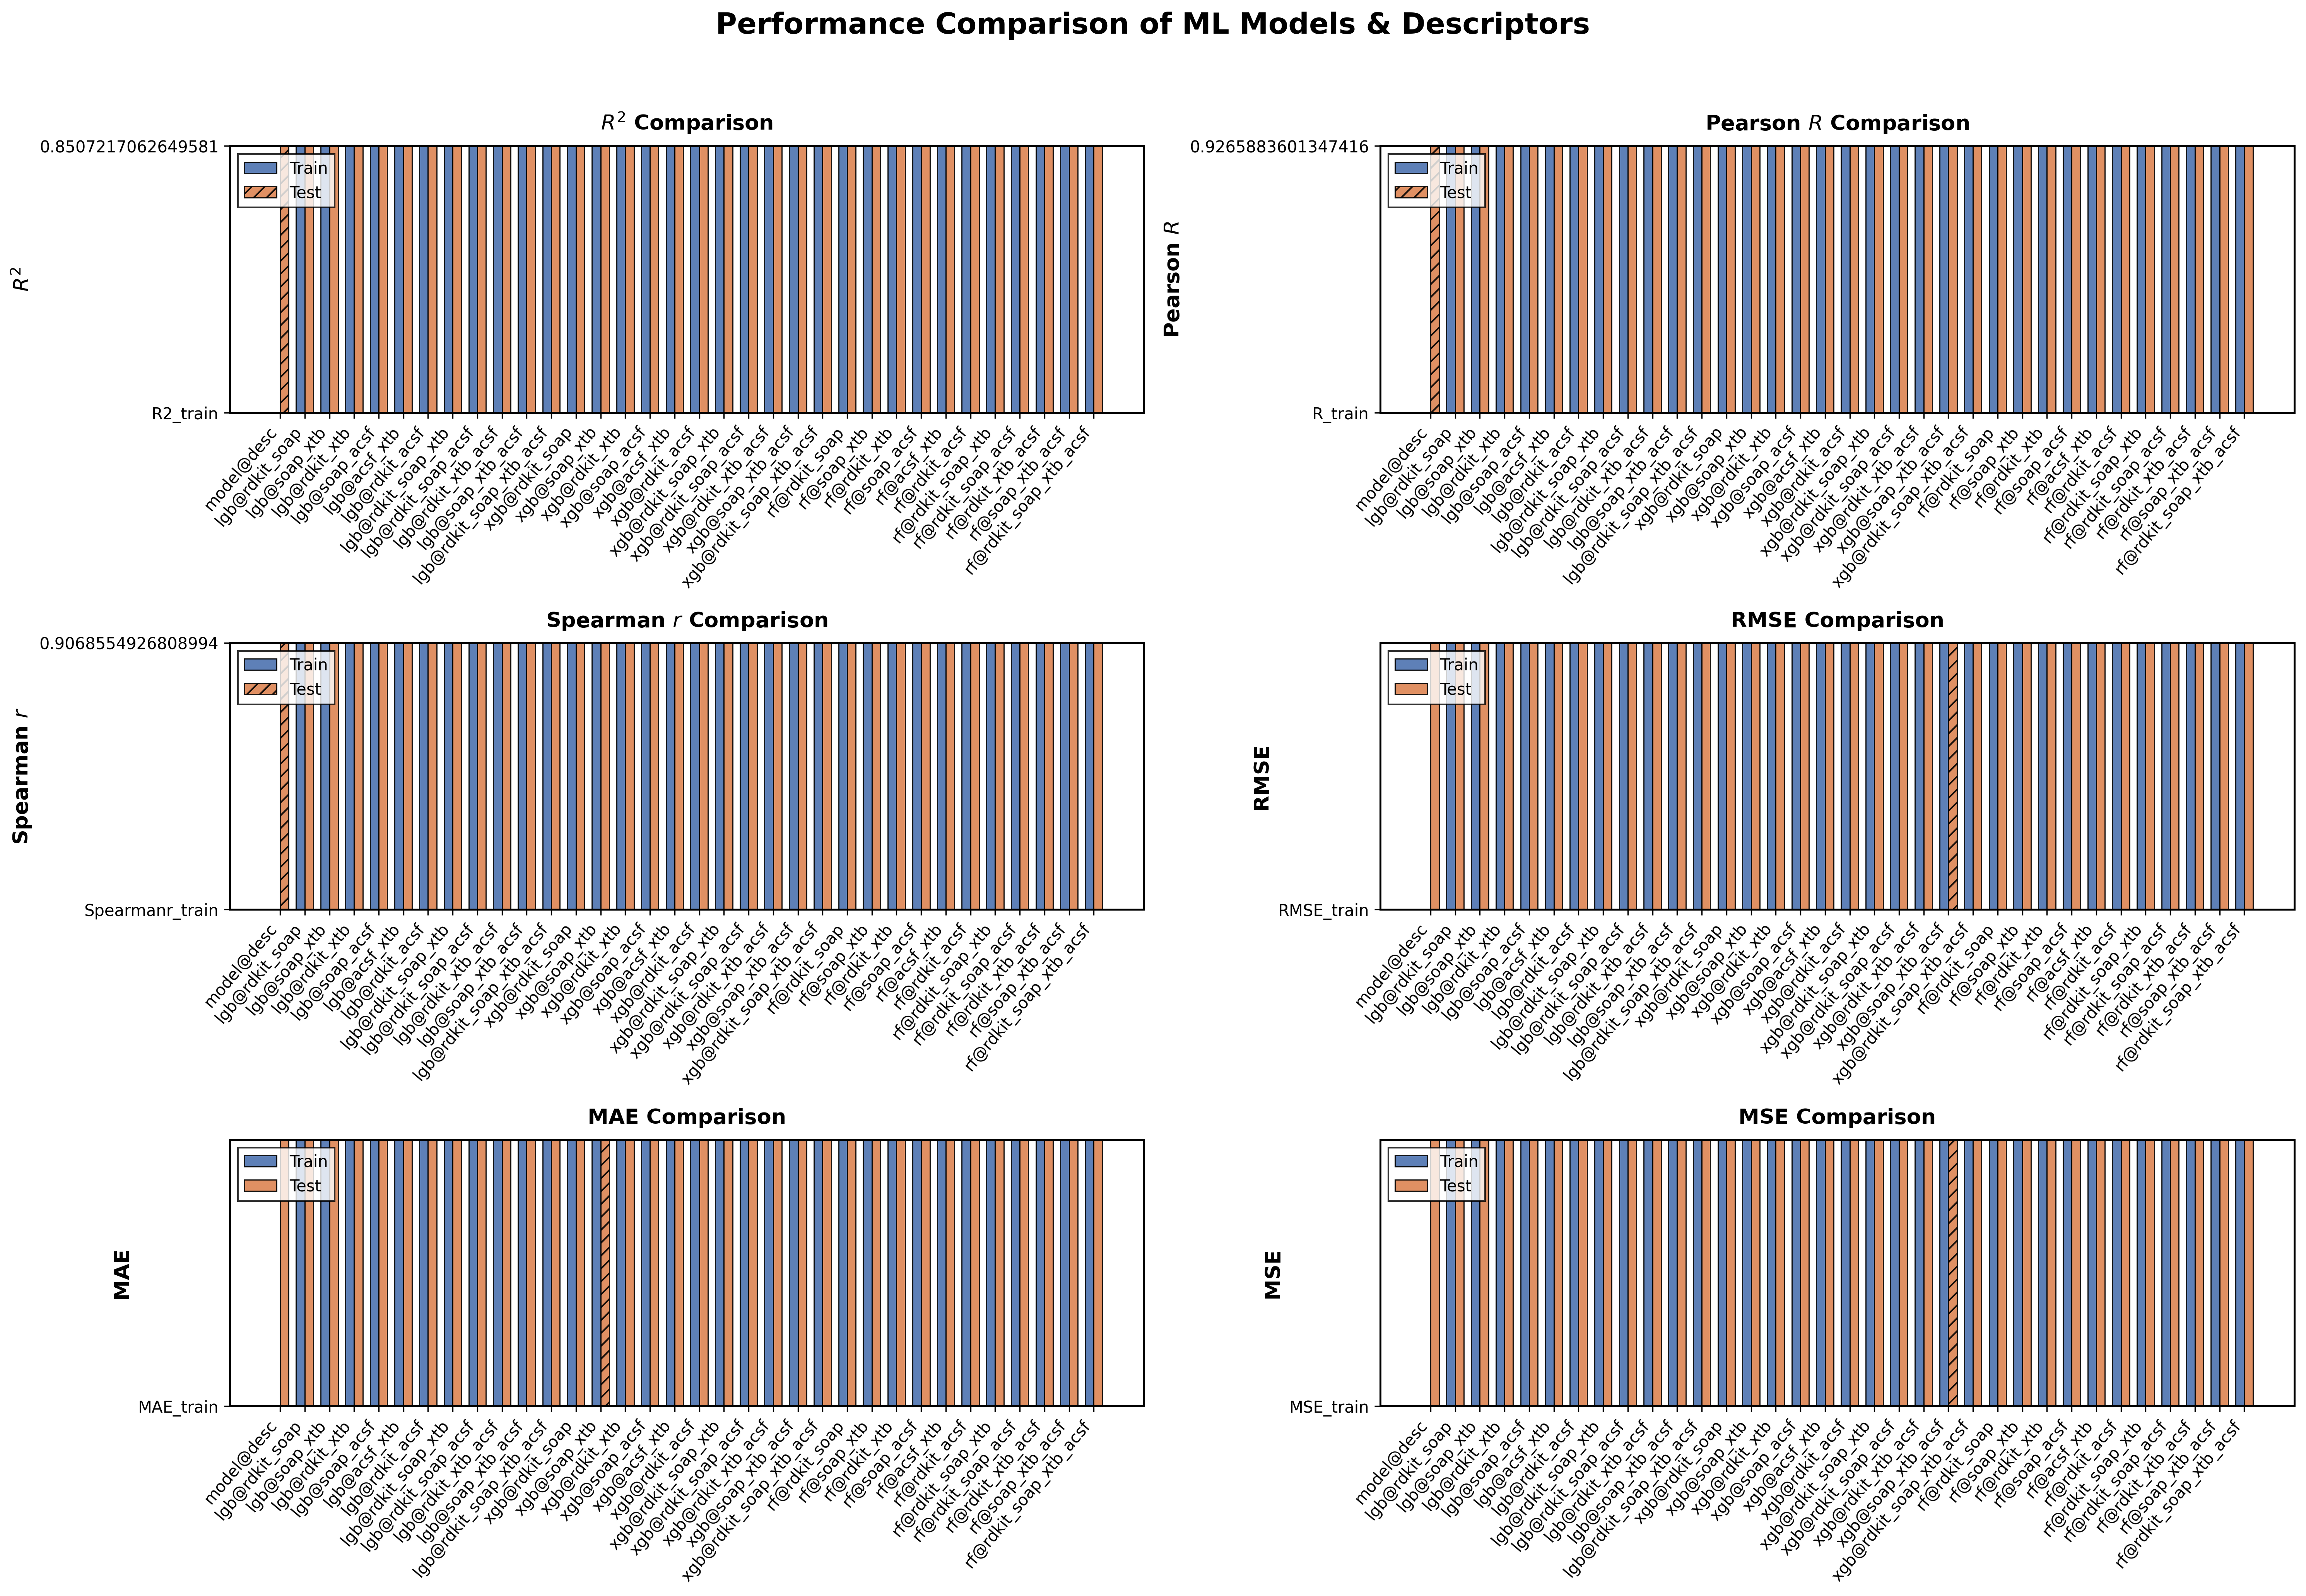

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ====================== 1. 加载数据 ======================
df = pd.read_csv('/home/iaw/DATA/AAReact/train/train.csv')
models = df['model'].values
descs = df['desc'].values

# 提取所有指标
r2_train, r2_test = df['R2_train'].values, df['R2_test'].values
r_train, r_test = df['R_train'].values, df['R_test'].values
spear_train, spear_test = df['Spearmanr_train'].values, df['Spearmanr_test'].values
mse_train, mse_test = df['MSE_train'].values, df['MSE_test'].values
mae_train, mae_test = df['MAE_train'].values, df['MAE_test'].values
rmse_train, rmse_test = df['RMSE_train'].values, df['RMSE_test'].values

# X 标签：model@desc 格式
labels = [f'{m}@{d}' for m, d in zip(models, descs)]
n = len(labels)
x = np.arange(n)
width = 0.35

# ====================== 2. 绘图样式（SCI 标准） ======================
plt.rcParams.update({
    #'font.family': 'Times New Roman',
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.linewidth': 1.2,
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf'
})


def plot_metric(ax, train, test, title, ylabel, ylim, is_loss=False):
    if is_loss:
        best_idx = np.argmin(test)
    else:
        best_idx = np.argmax(test)


    ax.bar(x - width/2, train, width, 
           color='#4C72B0', alpha=0.9, edgecolor='black', lw=0.7, label='Train')

    bars_test = ax.bar(x + width/2, test, width,
                       color='#DD8452', alpha=0.9, edgecolor='black', lw=0.7, label='Test')

 
    bars_test[best_idx].set_hatch('///')


    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=50, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.legend(frameon=True, edgecolor='black', fancybox=False)
    ax.set_ylim(ylim)

fig, axes = plt.subplots(3, 2, figsize=(20, 14))
axes = axes.flatten()

# 越大越好（R2, R, Spearman）
plot_metric(axes[0], r2_train, r2_test, '$R^2$ Comparison', '$R^2$', ylim=(0, 1.0), is_loss=False)
plot_metric(axes[1], r_train, r_test, 'Pearson $R$ Comparison', 'Pearson $R$', ylim=(0, 1.0), is_loss=False)
plot_metric(axes[2], spear_train, spear_test, 'Spearman $r$ Comparison', 'Spearman $r$', ylim=(0, 1.0), is_loss=False)

# 越小越好（RMSE, MAE, MSE）
plot_metric(axes[3], rmse_train, rmse_test, 'RMSE Comparison', 'RMSE', ylim=(0, 0.48), is_loss=True)
plot_metric(axes[4], mae_train, mae_test, 'MAE Comparison', 'MAE', ylim=(0, 0.42), is_loss=True)
plot_metric(axes[5], mse_train, mse_test, 'MSE Comparison', 'MSE', ylim=(0, 0.22), is_loss=True)

# 整体标题
fig.suptitle('Performance Comparison of ML Models & Descriptors', fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Hypered_best_model_metrics.png', dpi=600)

